## Satisfaction by Tenure

This notebook carries out a simulation experiment to explore the relationship between tenure at the job and satisfaction.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

survey = pd.read_csv("satisfaction_survey.txt", sep="\t")
survey.head()


,employee_id,gender,location,tenure,satisfaction
0,AQ1600314,man,Seattle,0.9,4
1,AQ1808649,man,Seattle,4.3,4
2,AQ1850081,man,New York,1.2,4
3,AQ1929192,man,Seattle,1.5,4
4,AQ1238345,man,New York,NaN,4


### Create two tenure groups

In [3]:
survey["tenure_group"] = np.where(survey["tenure"] < 1.5, "new", "old")
survey["tenure_group"].value_counts()


tenure_group
old    178
new    122
Name: count, dtype: int64

### Run experiments

- Let's calculate the mean satisfaction for the new employees
- Our experiment will be to select a sample of 25 people from the "olds" and compute their satisfaction

In [4]:
# Mean satisfaction for the "new" group
mean_new = survey.loc[survey["tenure_group"] == "new", "satisfaction"].mean()

old_means = []

for _ in range(5_000) : 
    old_means.append(
        # Draw 25 random samples of "old" satisfaction
        survey.loc[survey["tenure_group"] == "old", "satisfaction"]
            .sample(25)
            .mean()
    )

# Store in DataFrame
results = pd.DataFrame({"sample_mean": old_means})


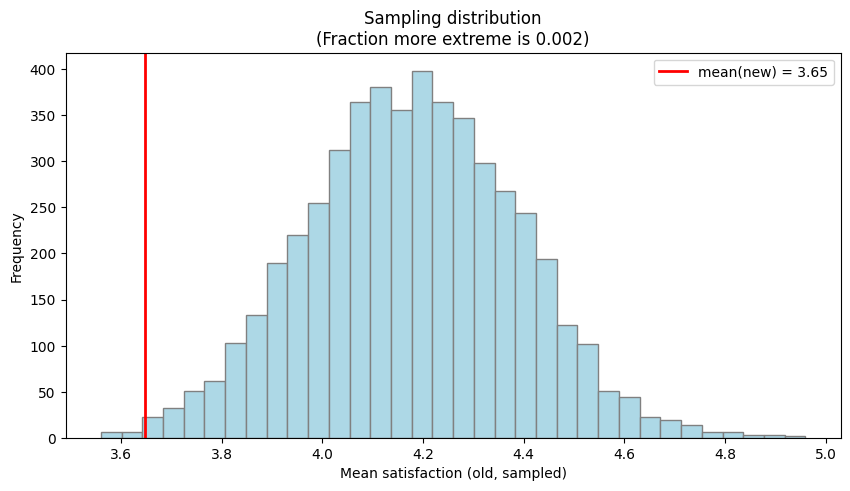

In [5]:
plt.figure(figsize=(10,5))
plt.hist(results["sample_mean"], bins=34, color="lightblue", edgecolor="gray")
plt.axvline(mean_new, color="red", linewidth=2, label=f"mean(new) = {mean_new:.2f}")

# Highlight “extreme” values where old sample mean ≤ new mean
extreme = (results["sample_mean"] <= mean_new).mean()
plt.title(f"Sampling distribution\n(Fraction more extreme is {extreme:.3f})")
plt.xlabel("Mean satisfaction (old, sampled)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
